## Example of loading OIR image data and metadata

In [1]:
from oir_loader import read_oir
from AB_ImVision import interactive_slice_viewer 
import numpy as np

In [2]:
file_path = r"P:\TNW\BMPI\Data\Arnon A.B\Data\20251119_ConfocalScan_SampleGlasWaterGlas_ArnonA.B\20251119_Layers_Glas_Water_Glas_3Dscan_UV_10X_v2.1.oir"

img, metadata = read_oir(file_path)

Starting JVM...


In [3]:
interactive_slice_viewer(np.squeeze(img))

interactive(children=(IntSlider(value=0, description='Slice Index', max=233), Dropdown(description='Slice Dire…

In [4]:
def pretty_omexml(xml: str) -> str:
    return xml.replace("><", ">\n<")

xml_str = str(metadata)
print(pretty_omexml(xml_str))


<ome:OME xmlns:ome="http://www.openmicroscopy.org/Schemas/OME/2016-06" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.openmicroscopy.org/Schemas/OME/2016-06 http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd">
<ome:Instrument ID="Instrument:0">
<ome:Laser ID="LightSource:0:0" Model="LD405_65792" Wavelength="405.0" WavelengthUnit="nm" />
<ome:Laser ID="LightSource:0:1" Model="LD488_65794" />
<ome:Laser ID="LightSource:0:2" Model="LD514_65795" />
<ome:Laser ID="LightSource:0:3" Model="LD561_65796" />
<ome:Laser ID="LightSource:0:4" Model="LD640_65798" />
<ome:Laser ID="LightSource:0:5" Model="AUXOUT_131329" />
<ome:Detector Gain="1.0" ID="Detector:0:0" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:1" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:2" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:3" Offset="0.0" Voltage="0.0" Vo

In [10]:
# Access the first image in the file
pixels = ome.image(0).Pixels

# Get pixel sizes and units
pixel_size_x = pixels.PhysicalSizeX
pixel_size_y = pixels.PhysicalSizeY
pixel_size_z = pixels.PhysicalSizeZ
unit_x = pixels.PhysicalSizeXUnit
unit_y = pixels.PhysicalSizeYUnit
unit_z = pixels.PhysicalSizeZUnit

print("Pixel size X:", pixel_size_x, unit_x)
print("Pixel size Y:", pixel_size_y, unit_y)
print("Pixel size Z:", pixel_size_z, unit_z)

Pixel size X: 2.485922277608956 µm
Pixel size Y: 2.485922277608956 µm
Pixel size Z: 15.0 µm


# The code below provides no benefits over the code used above!!!

The code below shows how to use the bioformats package to load images. This is the package that is used by the read_oir function. The code below is added to see how bioformats can be used directely, but using the read_oir funcion is suggested. 

# read single 2D slice (single channel, z location, time point)

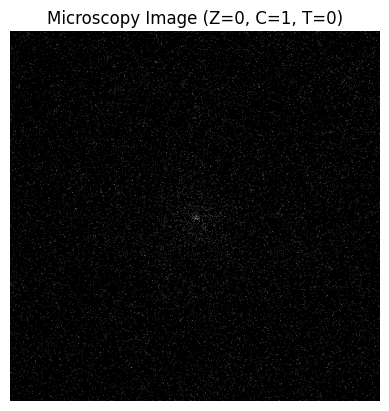

In [8]:
import bioformats
import matplotlib.pyplot as plt
# Read the image
reader = bioformats.ImageReader(file_path)
image = reader.read(z=0, c=0, t=0, rescale=False)

# Display with matplotlib
plt.imshow(image, cmap='gray')
plt.title("Microscopy Image (Z=0, C=1, T=0)")
plt.axis('off')
plt.show()

## Obtaining metadat using the bioformats package

This is the package used by the read_oir function.

In [9]:
# Get metadata using the OME metadata store
metadata = bioformats.get_omexml_metadata(file_path)
ome = bioformats.OMEXML(metadata)

# Access the first image in the file
pixels = ome.image(0).Pixels

# Get pixel sizes and units
pixel_size_x = pixels.PhysicalSizeX
pixel_size_y = pixels.PhysicalSizeY
pixel_size_z = pixels.PhysicalSizeZ
unit_x = pixels.PhysicalSizeXUnit
unit_y = pixels.PhysicalSizeYUnit
unit_z = pixels.PhysicalSizeZUnit

print("Pixel size X:", pixel_size_x, unit_x)
print("Pixel size Y:", pixel_size_y, unit_y)
print("Pixel size Z:", pixel_size_z, unit_z)

Pixel size X: 2.485922277608956 µm
Pixel size Y: 2.485922277608956 µm
Pixel size Z: 15.0 µm
